# 1. Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay,
    PrecisionRecallDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

# 2. Carregamento dos Dados

In [2]:
df = pd.read_csv('UCI_Credit_Card.csv')
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


# 3. Inspeção Inicial

In [3]:
print(df.info())
print(df.describe())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

# 4. EDA - Distribuição da Classe

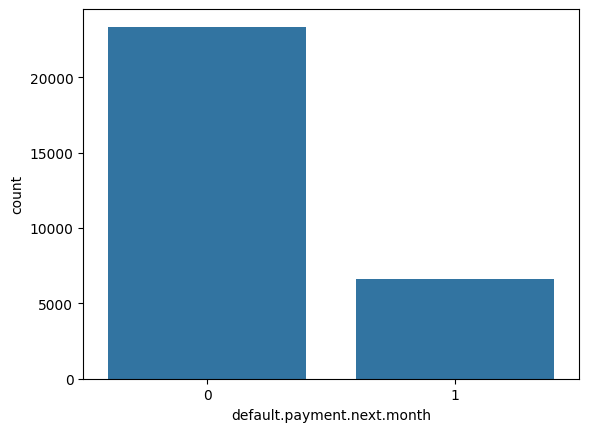

default.payment.next.month
0    0.7788
1    0.2212
Name: proportion, dtype: float64


In [4]:
sns.countplot(x='default.payment.next.month', data=df)
plt.show()

print(df['default.payment.next.month'].value_counts(normalize=True))

# 5. EDA - Correlação

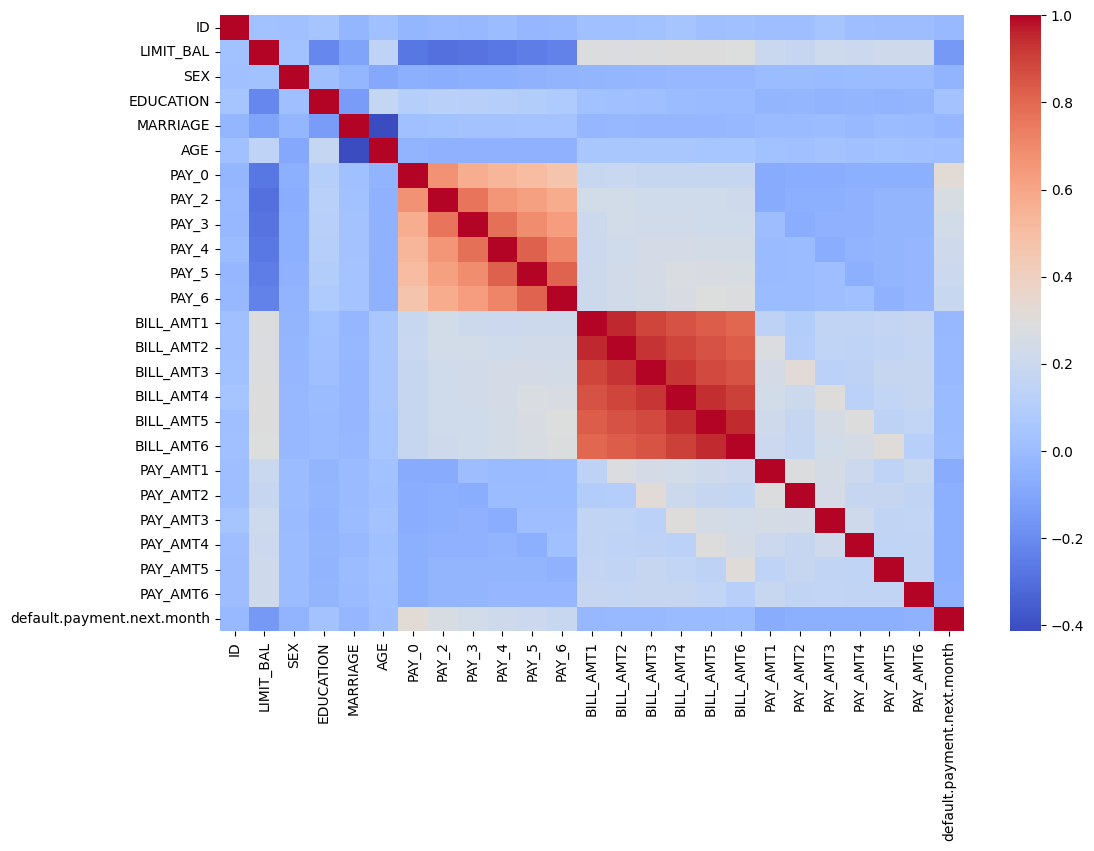

In [5]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()

# 6. EDA - Variáveis Importantes

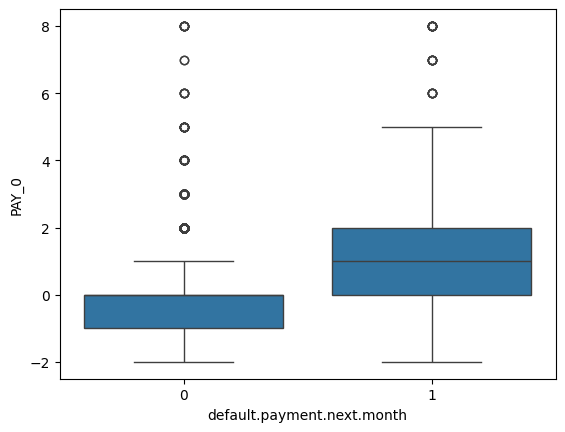

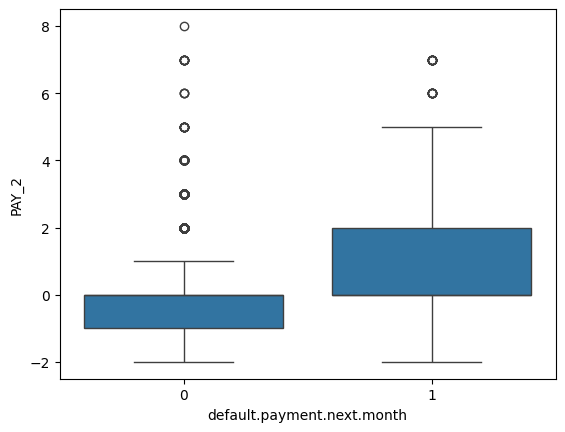

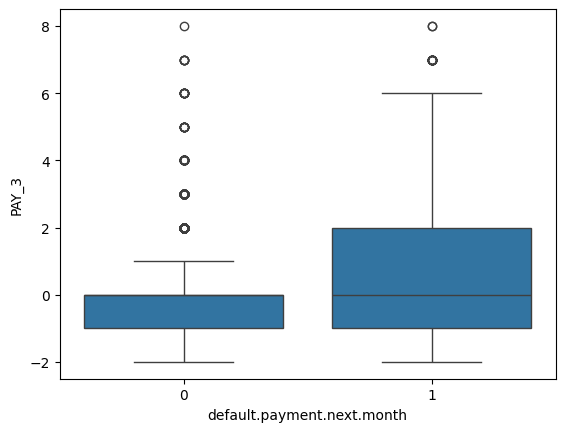

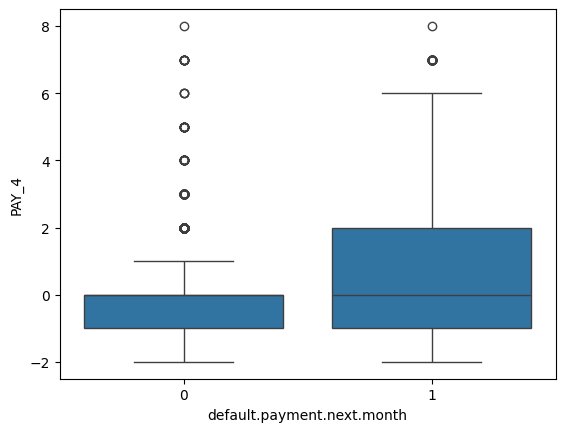

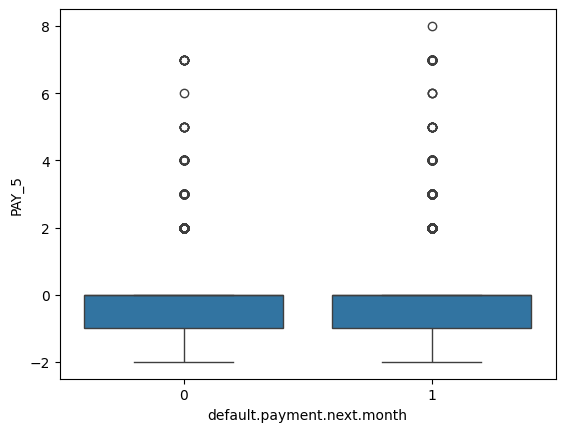

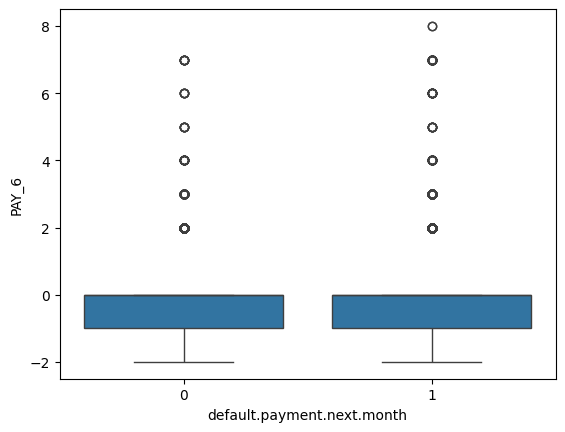

In [6]:
for col in ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']:
    plt.figure()
    sns.boxplot(x='default.payment.next.month', y=col, data=df)
    plt.show()

# 7. Feature Engineering

In [12]:
df = df.drop(columns=['ID'], errors='ignore')

df['TOTAL_BILL'] = sum(df[f'BILL_AMT{i}'] for i in range(1,7))
df['TOTAL_PAY'] = sum(df[f'PAY_AMT{i}'] for i in range(1,7))
df['PAY_RATIO'] = df['TOTAL_PAY']/(df['TOTAL_BILL']+1)

# 8. Separação das Variáveis

In [13]:
X = df.drop('default.payment.next.month', axis=1)
y = df['default.payment.next.month']

# 9. Treino, Validação e Teste

In [14]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

# 10. Normalização sem Data Leakage

In [15]:
num_cols = ['LIMIT_BAL'] + [f'BILL_AMT{i}' for i in range(1,7)] + [f'PAY_AMT{i}' for i in range(1,7)] + ['TOTAL_BILL','TOTAL_PAY','PAY_RATIO']

scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_val[num_cols] = scaler.transform(X_val[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# 11. Balanceamento com SMOTE

In [16]:
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# 12. Modelos

In [17]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=10,
        class_weight='balanced', random_state=42),
    'XGBoost': XGBClassifier(
        n_estimators=300, learning_rate=0.05,
        max_depth=5, subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42)
}

# 13. Cross Validation

In [18]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    scores = cross_val_score(model, X_train_bal, y_train_bal,
                             cv=cv, scoring='roc_auc')
    print(name, scores.mean())

Logistic Regression 0.7632737822471286
Random Forest 0.8488303547820862
XGBoost 0.8953478784545847


# 14. Avaliação Final

In [19]:
results = []

for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    auc = roc_auc_score(y_test, y_prob)

    results.append({
        'Modelo': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'AUC': auc
    })

    print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.71      0.78      3504
           1       0.38      0.63      0.47       996

    accuracy                           0.69      4500
   macro avg       0.62      0.67      0.62      4500
weighted avg       0.76      0.69      0.71      4500

              precision    recall  f1-score   support

           0       0.87      0.84      0.86      3504
           1       0.50      0.58      0.54       996

    accuracy                           0.78      4500
   macro avg       0.69      0.71      0.70      4500
weighted avg       0.79      0.78      0.79      4500

              precision    recall  f1-score   support

           0       0.86      0.86      0.86      3504
           1       0.51      0.52      0.52       996

    accuracy                           0.78      4500
   macro avg       0.69      0.69      0.69      4500
weighted avg       0.78      0.78      0.78      4500



# 15. Matriz de Confusão

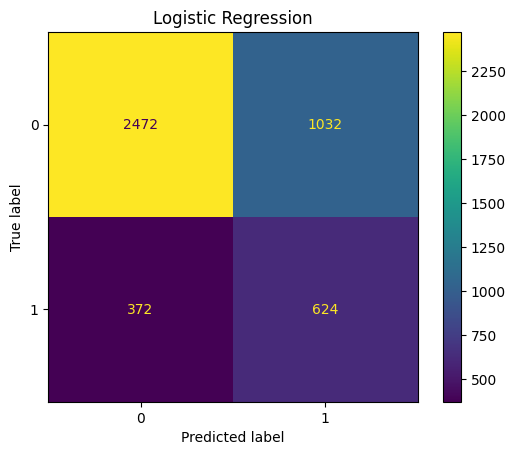

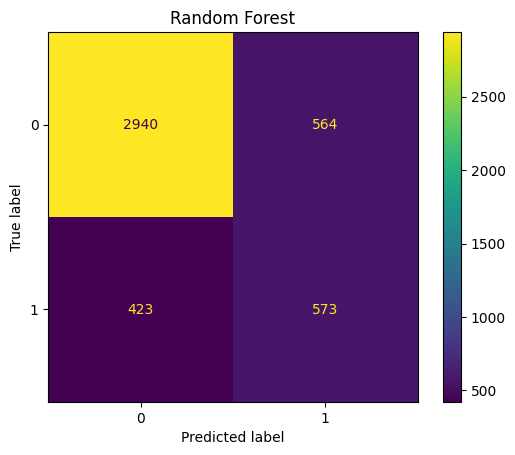

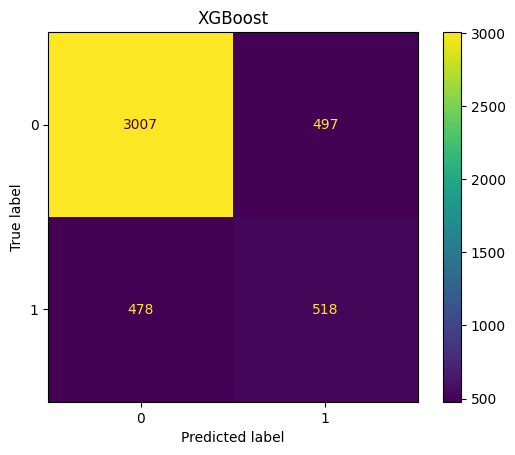

In [20]:
for name, model in models.items():
    y_pred = model.predict(X_test)
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    plt.title(name)
    plt.show()

# 16. Curvas ROC e Precision-Recall

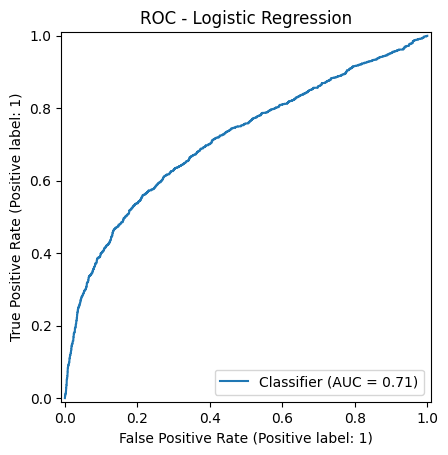

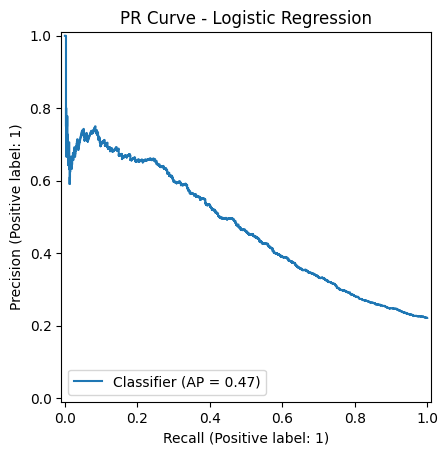

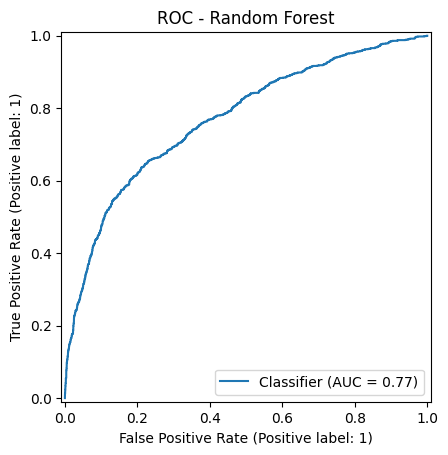

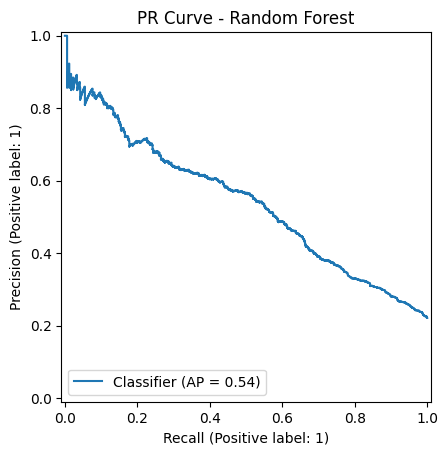

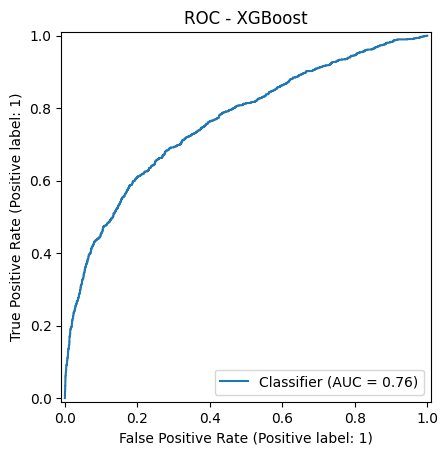

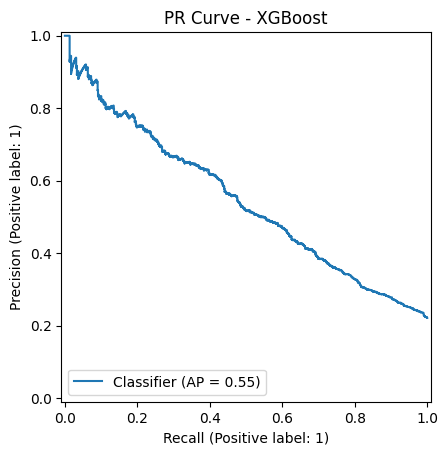

In [21]:
for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:,1]

    RocCurveDisplay.from_predictions(y_test, y_prob)
    plt.title(f'ROC - {name}')
    plt.show()

    PrecisionRecallDisplay.from_predictions(y_test, y_prob)
    plt.title(f'PR Curve - {name}')
    plt.show()

# 17. Comparação dos Modelos

In [22]:
resultados_df = pd.DataFrame(results)
resultados_df.sort_values('AUC', ascending=False)

,Modelo,Accuracy,Precision,Recall,F1,AUC
1,Random Forest,0.780667,0.503958,0.575301,0.537271,0.770289
2,XGBoost,0.783333,0.510345,0.520080,0.515167,0.762611
0,Logistic Regression,0.688000,0.376812,0.626506,0.470588,0.713573


# 18. Feature Importance XGBoost

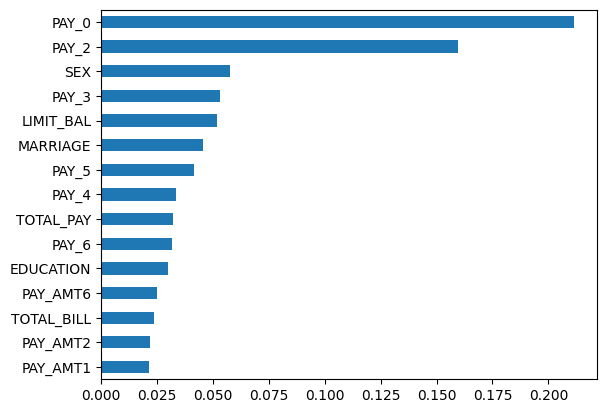

In [23]:
best_model = models['XGBoost']
best_model.fit(X_train_bal, y_train_bal)

importances = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values()

importances.tail(15).plot(kind='barh')
plt.show()

# 19. Salvamento do Modelo

In [24]:
joblib.dump(best_model, 'modelo_final.joblib')
joblib.dump(scaler, 'scaler.joblib')

['scaler.joblib']

# 20. Conclusões

In [25]:
print('Modelo final: XGBoost')
print('Data leakage corrigido')
print('SMOTE aplicado')
print('Feature engineering aplicada')
print('Modelo salvo para uso no Streamlit')

Modelo final: XGBoost
Data leakage corrigido
SMOTE aplicado
Feature engineering aplicada
Modelo salvo para uso no Streamlit


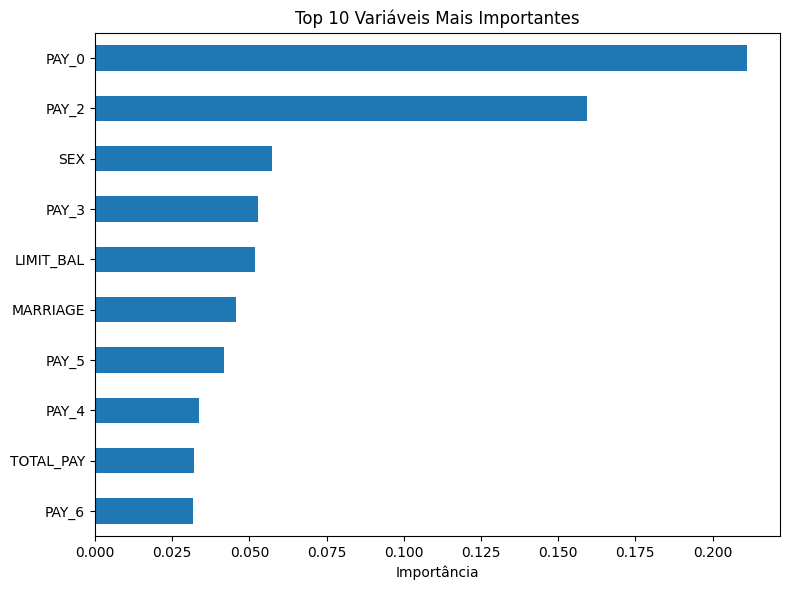

In [35]:
import pandas as pd

importancias = pd.Series(
    best_model.feature_importances_,
    index=X.columns
)

importancias = importancias.sort_values(ascending=True)

plt.figure(figsize=(8,6))

importancias.tail(10).plot(
    kind='barh'
)

plt.title('Top 10 Variáveis Mais Importantes')

plt.xlabel('Importância')

plt.tight_layout()
plt.show()